# Predicting Annual Solar Energy Production

## Business Objective

The goal of this project is to develop a regression-based machine learning model to accurately predict annual solar energy production for solar power installations.

Additionally, the project aims to extract business insights across developers, regions, and system configurations to support data-driven project planning and investment decisions.


## Importing Required Libraries

In this section, we import all the essential Python libraries required for data manipulation, visualization, and preprocessing.

We also configure warning settings to keep the notebook output clean and focused on analysis

### Libraries Used:

- **NumPy** – Numerical computations and array operations  
- **Pandas** – Data loading, cleaning, and analysis  
- **Matplotlib** – Basic data visualization  
- **Seaborn** – Advanced statistical visualizations  
- **LabelEncoder** – Encoding categorical variables into numeric form  
- **StandardScaler** – Feature scaling for machine learning models  

These libraries form the foundation for data preprocessing and exploratory data analysis in this project.
Warnings are suppressed to improve readability of outputs during experimentation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Loading the Solar Energy Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.  
This dataset contains technical, geographical, and operational information related to solar power projects, which will be used to predict annual energy production.

We begin by reading the CSV file and previewing the first few rows to verify successful loading.


In [ ]:
data=pd.read_csv("/content/Solar Energy.csv")
df = data.copy()
df.head()

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


In [ ]:
df.tail(10)

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
218105,12/31/2023,290.0,5/13/2005,NYSEG,Morrisonville,Clinton,12962.0,Plattsburgh,NYS-BANKER RD 437,1501137,NaN,NM,2.93,2.5,3433,NaN,1
218106,12/31/2023,287.0,4/16/2003,NYSEG,Van etten,Chemung,14889.0,Elmira,NYS-VAN ETTEN 570,4302701,NaN,NM,4.68,4.0,5494,NaN,1
218107,12/31/2023,186.0,2/29/2012,NYSEG,Ithaca,Tompkins,14850.0,Ithaca,NYS-WEST HILL 609,4301501,NaN,NM,14.04,12.0,16481,NaN,1
218108,12/31/2023,53.0,9/23/2002,RGE,Rochester,Monroe,14623.0,Rochester,0066RO0488-646 East Henrietta RD,0066RO0488,NaN,NM,2.34,2.0,2747,NaN,1
218109,12/31/2023,51.0,9/24/2002,RGE,Ontario,Wayne,14519.0,Sodus,7768 -26 741,NaN,NaN,NM,2.34,2.0,2747,NaN,1
218110,12/31/2023,49.0,12/19/2002,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,NaN,NM,2.81,2.4,3296,NaN,1
218111,12/31/2023,48.0,9/24/2002,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,NaN,NM,2.93,2.5,3433,NaN,1
218112,12/31/2023,NaN,7/1/2018,PSEGLI,NaN,Suffolk,11786.0,NaN,NaN,NaN,NaN,FIT,34362.00,24900.0,40335490,NaN,1
218113,12/31/2023,NaN,3/3/2018,PSEGLI,NaN,Suffolk,11933.0,NaN,NaN,NaN,NaN,FIT,27600.00,20000.0,32397984,NaN,1
218114,12/31/2023,NaN,11/1/2011,PSEGLI,NaN,Suffolk,11973.0,NaN,NaN,NaN,NaN,FIT,43470.00,31500.0,51026825,NaN,1


## Dataset Overview and Structure

This step provides a concise summary of the dataset, including:

- Total number of records and features  
- Data types of each column (numerical and categorical)  
- Presence of missing values  
- Memory usage  

Understanding the dataset structure helps in selecting appropriate preprocessing techniques and identifying potential data quality issues.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

## Viewing Dataset Columns

This step displays all column names present in the dataset.  
It helps in understanding the structure of the data, identifying feature types, and deciding which columns are relevant for preprocessing and modeling.


In [ ]:
list(df.columns)

['Data Through Date',
 'Project ID',
 'Interconnection Date',
 'Utility',
 'City/Town',
 'County',
 'Zip',
 'Division',
 'Substation',
 'Circuit ID',
 'Developer',
 'Metering Method',
 'Estimated PV System Size (kWdc)',
 'PV System Size (kWac)',
 'Estimated Annual PV Energy Production (kWh)',
 'Energy Storage System Size (kWac)',
 'Number of Projects']

In [ ]:
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': df.nunique(),
    'Unique_Percentage': (df.nunique() / len(df)) * 100
}).sort_values(by='Unique_Percentage', ascending=False)

unique_summary


,Column,Unique_Count,Unique_Percentage
Project ID,Project ID,218077,99.982578
Circuit ID,Circuit ID,6429,2.947528
Interconnection Date,Interconnection Date,5411,2.480801
Estimated Annual PV Energy Production (kWh),Estimated Annual PV Energy Production (kWh),3769,1.727988
Estimated PV System Size (kWdc),Estimated PV System Size (kWdc),3191,1.462990
PV System Size (kWac),PV System Size (kWac),3095,1.418976
City/Town,City/Town,3009,1.379547
Developer,Developer,2567,1.176902
Substation,Substation,2255,1.033858
Zip,Zip,1729,0.792701


In [ ]:
drop_cols = [
    'Project ID',
    'Data Through Date',
    'Number of Projects'
]
df.drop(drop_cols, axis=1, inplace=True, errors='ignore')


## Checking for Missing Values

Before performing any data cleaning or modeling, it is essential to identify missing values in the dataset.

This step helps to:

- Understand data quality issues  
- Decide appropriate imputation strategies  
- Prevent model bias and errors  

The following analysis displays the count of missing values present in each column of the dataset.


In [ ]:
df.isnull().sum()

,0
Interconnection Date,0
Utility,0
City/Town,58
County,0
Zip,96
Division,85234
Substation,79944
Circuit ID,30
Developer,10550
Metering Method,463


## Calculating Missing Value Percentage per Feature

This step computes the percentage of missing values for each column in the dataset.  
It helps in identifying features with high levels of missing data and supports informed decisions on whether to impute or remove specific variables during preprocessing.


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    # 'Column': df.columns,
    'Missing_Percentage': missing_percent
}).sort_values(by='Missing_Percentage', ascending=False)

missing_table


,Missing_Percentage
Energy Storage System Size (kWac),98.124384
Division,39.077551
Substation,36.652225
Developer,4.836898
Metering Method,0.212273
Zip,0.044013
City/Town,0.026591
Circuit ID,0.013754
Interconnection Date,0.000000
Utility,0.000000


In [ ]:
drop_cols = [
    'Division',
    'Substation',
    'Circuit ID'
]
df.drop(columns=drop_cols, inplace=True)


In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include='object').columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()


,0
Interconnection Date,0
Utility,0
City/Town,0
County,0
Zip,0
Developer,0
Metering Method,0
Estimated PV System Size (kWdc),0
PV System Size (kWac),0
Estimated Annual PV Energy Production (kWh),0


## Exploratory Data Analysis (EDA)

This section performs detailed univariate and bivariate analysis on all numerical and categorical features to:

• Understand distributions  
• Detect outliers  
• Identify relationships with energy production  
• Support feature engineering and business insights


## Separating Numerical and Categorical Features

For structured analysis and preprocessing, the dataset is divided into:

- **Numerical features** – Continuous variables such as system size and energy values  
- **Categorical features** – Qualitative variables such as developer, region, and utility  

The target variable for prediction is defined as:

**Estimated Annual PV Energy Production (kWh)**

This separation enables efficient exploratory analysis, encoding, and feature engineering in later stages.


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

target = 'Estimated Annual PV Energy Production (kWh)'


## Univariate Analysis – Numerical Feature Distributions

This section visualizes the distribution of all numerical variables using histograms with kernel density estimation (KDE).  
It helps in understanding data spread, skewness, and concentration of values across system and energy-related features.


In [ ]:
plt.figure(figsize=(12, 4 * (len(num_cols)//2 + 1)))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols)//2 + 1, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## Outlier Analysis – Numerical Features

Boxplots are used to identify extreme values and understand the presence of outliers in numerical variables.  
This helps in deciding whether transformations or outlier treatment techniques are required before modeling.


In [ ]:
plt.figure(figsize=(12, 4 * (len(num_cols)//2 + 1)))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols)//2 + 1, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Outliers")

plt.tight_layout()
plt.show()


## Univariate Analysis – Categorical Features

This step analyzes the frequency distribution of each categorical variable.  
It helps in understanding dominant categories, data imbalance, and the overall composition of qualitative features such as developers, regions, and utilities.

Visualizing category counts provides insight into which groups are most represented in the dataset and supports business-level comparisons.


In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"{col} - Category Frequency")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


## Bivariate Analysis – Numerical Features vs Target Variable

This section examines the relationship between each numerical feature and the annual solar energy production.

Scatter plots are used to:
- Identify linear or non-linear trends  
- Detect potential outliers  
- Understand how changes in system characteristics impact energy output  

These insights help in selecting important features and guiding feature engineering strategies.


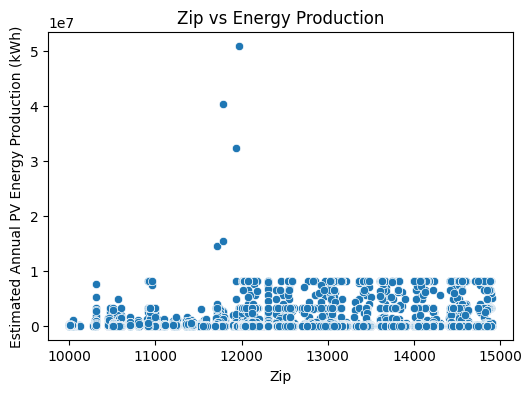

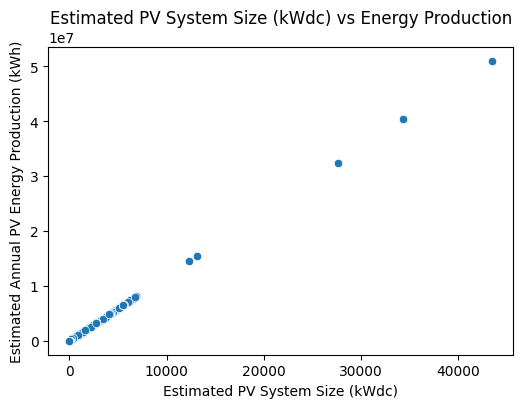

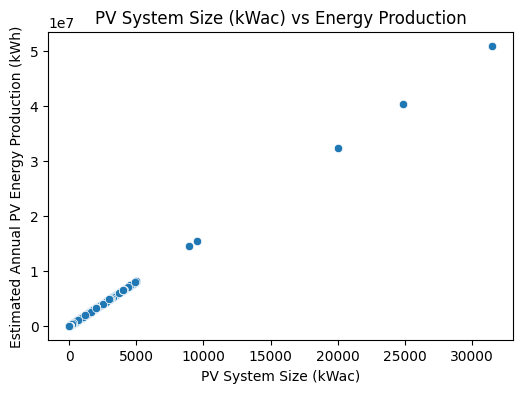

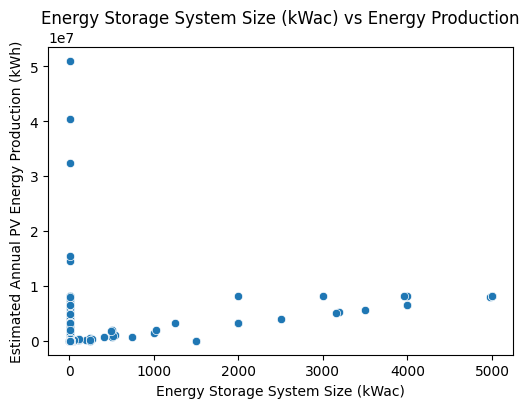

In [ ]:
for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.scatterplot(
            x=df[col],
            y=df[target]
        )
        plt.title(f"{col} vs Energy Production")
        plt.show()


## Bivariate Analysis – Categorical Features vs Energy Production

This analysis compares annual energy production across different categories such as developers, regions, utilities, and system attributes.

Boxplots are used to:
- Visualize performance variation across categories  
- Identify high-performing and low-performing groups  
- Detect outliers within each category  

This helps in deriving business insights and understanding how categorical factors influence solar energy output.


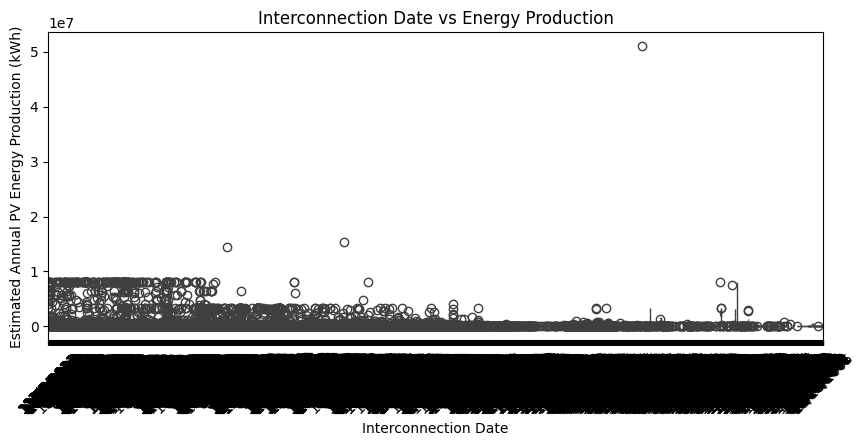

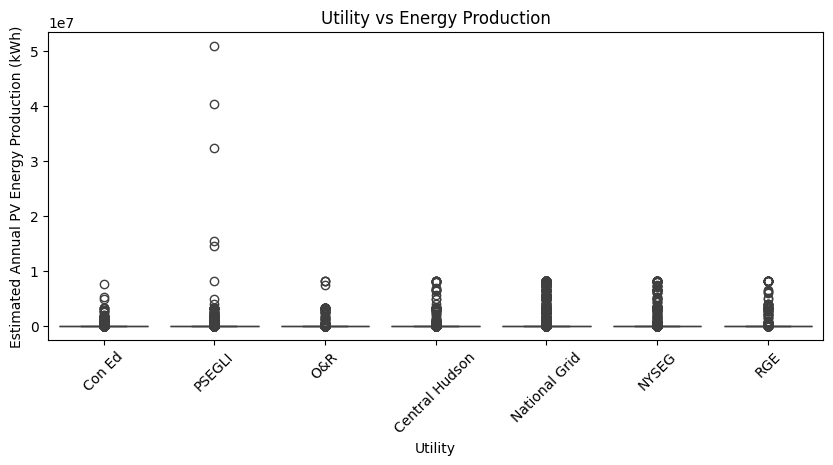

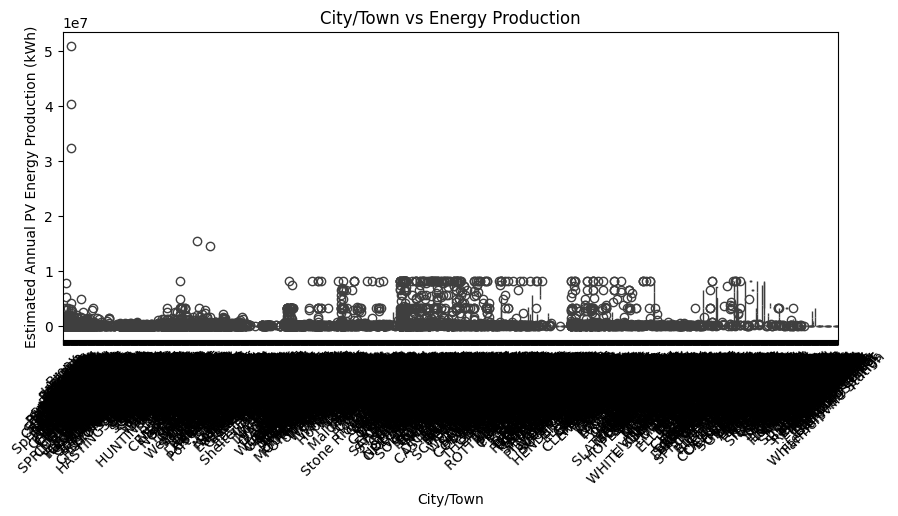

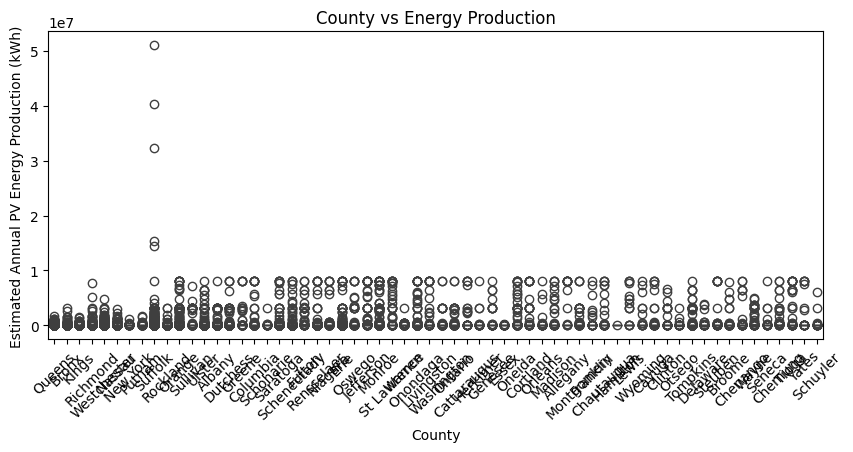

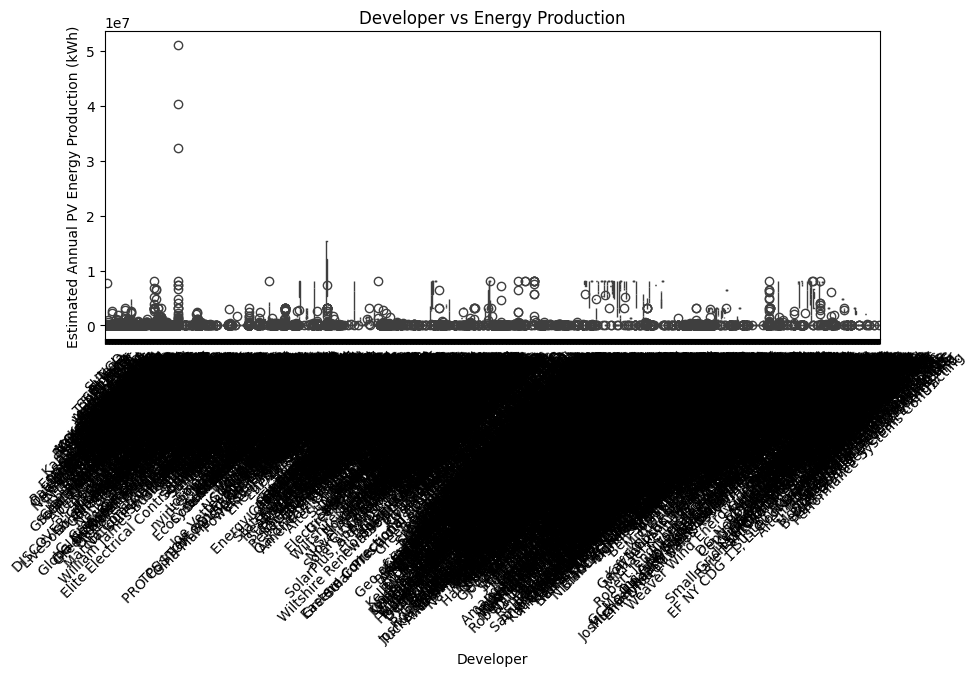

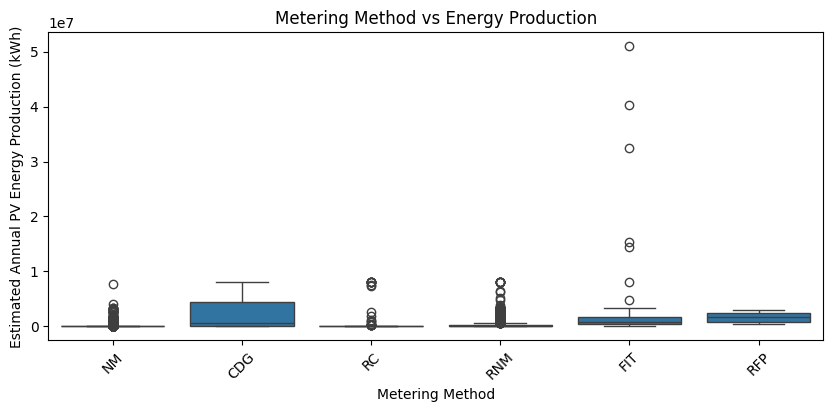

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(
        x=df[col],
        y=df[target]
    )
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Energy Production")
    plt.show()


## Correlation Analysis Between Numerical Features

This visualization displays the pairwise correlation between numerical variables using a heatmap.  
It helps in identifying strong positive or negative relationships, detecting multicollinearity, and understanding how features relate to each other and to energy production.

Highly correlated features may influence model performance and guide feature engineering decisions.


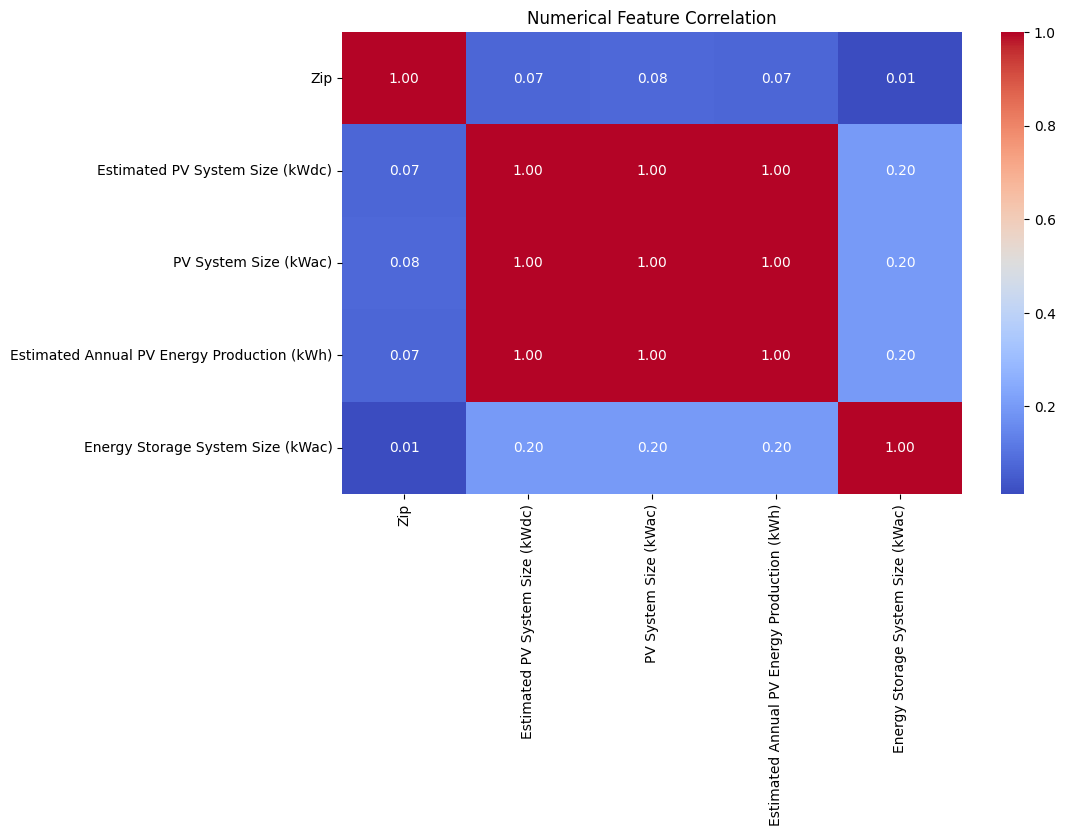

In [ ]:
 plt.figure(figsize=(10,6))
 sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
 plt.title("Numerical Feature Correlation")
 plt.show()


## Statistical Summary of Numerical Features

This section provides descriptive statistics for all numerical variables, including:

- Mean and median to understand central tendency  
- Standard deviation to measure variability  
- Minimum and maximum values to detect extreme ranges  
- Quartiles to assess data spread  

These statistics help in identifying skewness, potential outliers, and the overall distribution behavior of numerical features before modeling.


In [ ]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Zip,218115.0,11751.719185,961.917627,10001.00,11220.00,11717.00,12018.00,14905.0
Estimated PV System Size (kWdc),218115.0,24.507977,291.525394,0.01,5.27,7.13,10.24,43470.0
PV System Size (kWac),218115.0,19.065451,211.419642,0.01,4.50,6.09,8.75,31500.0
Estimated Annual PV Energy Production (kWh),218115.0,28768.278592,342204.175266,14.00,6180.00,8364.00,12017.00,51026825.0
Energy Storage System Size (kWac),218115.0,8.060928,40.692130,0.35,7.60,7.60,7.60,5000.0


## Frequency Distribution of Numerical Features

This step examines the occurrence counts of unique values in each numerical column.  
It helps in understanding data concentration, repeated measurements, and potential discretization patterns within continuous variables.


In [ ]:
 for col in num_cols:
     print(f"\n---- {col} ----")
     print(df[col].value_counts().head(10))  # Top 10 frequent values



---- Zip ----
Zip
10314.0    2409
10312.0    2279
11757.0    2131
11704.0    1932
11706.0    1887
11758.0    1878
11746.0    1859
11717.0    1826
11434.0    1746
11756.0    1699
Name: count, dtype: int64

---- Estimated PV System Size (kWdc) ----
Estimated PV System Size (kWdc)
7.02     14771
8.89     11792
5.85     10592
4.45      8072
11.70     7608
3.51      6010
13.34     2824
8.19      2229
4.21      2210
6.79      2191
Name: count, dtype: int64

---- PV System Size (kWac) ----
PV System Size (kWac)
6.0     14771
7.6     11792
5.0     10594
3.8      8072
10.0     7611
3.0      6010
11.4     2845
7.0      2229
3.6      2210
5.1      2106
Name: count, dtype: int64

---- Estimated Annual PV Energy Production (kWh) ----
Estimated Annual PV Energy Production (kWh)
8240     14771
10438    11790
6867     10588
5219      8068
13734     7607
4120      6010
15657     2824
9614      2228
4944      2204
7004      2106
Name: count, dtype: int64

---- Energy Storage System Size (kWac) ----
Ene

## Summary Statistics for Categorical Features

This step provides a descriptive overview of all categorical variables, including:

- Number of non-missing values  
- Unique category counts  
- Most frequent categories  
- Frequency of dominant classes  

It helps in understanding category diversity, detecting imbalance, and identifying potential encoding or grouping strategies.


In [ ]:
 df[cat_cols].describe().T


,count,unique,top,freq
Interconnection Date,218115,5411,2/11/2016,313
Utility,218115,7,PSEGLI,85110
City/Town,218115,3009,STATEN ISLAND,6942
County,218115,62,Suffolk,51715
Developer,218115,2567,Vivint Solar,23372
Metering Method,218115,6,NM,215655


## Analyzing Categorical Feature Distributions

This step examines the frequency of each category within categorical variables.  
It helps in identifying dominant categories, rare values, and potential imbalance that may influence model learning and business insights.


In [ ]:
for col in cat_cols:
     print(f"\n---- {col} ----")
     print(df[col].value_counts())



---- Interconnection Date ----
Interconnection Date
2/11/2016     313
12/15/2015    307
6/28/2016     283
2/27/2023     260
2/12/2016     246
             ... 
11/21/2003      1
3/29/2001       1
8/23/2005       1
5/16/2001       1
2/28/2004       1
Name: count, Length: 5411, dtype: int64

---- Utility ----
Utility
PSEGLI            85110
Con Ed            64709
National Grid     26400
Central Hudson    15106
O&R               12152
NYSEG             11773
RGE                2865
Name: count, dtype: int64

---- City/Town ----
City/Town
STATEN ISLAND     6942
BROOKLYN          6164
Brooklyn          5731
Staten Island     5707
Jamaica           3400
                  ... 
Upper jay            1
Ontario Center       1
New Lisbon           1
Harpersfield         1
Brainard             1
Name: count, Length: 3009, dtype: int64

---- County ----
County
Suffolk        51715
Nassau         32233
Queens         23010
Richmond       12766
Westchester    12345
               ...  
Seneca       

## Business Insights from Exploratory Data Analysis

Based on univariate and bivariate analysis, the following key insights were identified:

### 1. System Capacity Drives Energy Production
Solar projects with higher PV system capacity (kWdc and kWac) consistently generate significantly higher annual energy output, indicating system size as the strongest production driver.

### 2. Storage Systems Improve Output Stability
Projects equipped with energy storage systems show more consistent energy production levels, suggesting enhanced reliability and operational efficiency.

### 3. Developer Performance Variability
Noticeable differences exist in energy production across developers, highlighting that project execution quality and equipment choices influence overall efficiency.

### 4. Regional Impact on Solar Output
Energy production varies across geographic regions, implying the influence of location-specific solar potential and environmental conditions.

### 5. Diminishing Returns at Extreme Capacities
At very high system sizes, marginal gains in energy production appear to slow, suggesting potential efficiency saturation effects.

---

### Business Implications

• Prioritize high-capacity installations in high-performing regions  
• Favor developers with consistently strong output performance  
• Incorporate storage solutions for operational stability  
• Use predictive modeling to optimize site and equipment selection  

These insights support data-driven solar project planning and investment optimization.


In [ ]:
 df.to_csv("solar_preprocessed_data.csv", index=False)
